In [9]:
import pandas as pd
import csv
import numpy as np
import matplotlib.pyplot as plt
import os
import pyarrow.parquet as pq

In [3]:
data = pd.read_csv('amalgamated_data.csv')

C:\Users\maxch\AppData\Local\Temp\ipykernel_29264\4105916223.py:1: DtypeWarning: Columns (3,4,5,6,19,20,28,31,32,33,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,51,52,53,54,55,57,62,63,65,68,71,76,77,78,79,80,81,82,83,84,86,87,89,90,91,92,93,103,104,108,109,110,111,114,116,118,119,120,121,122,125) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('amalgamated_data.csv')


In [4]:
data.head()

,CASE_NUMBER,CASE_STATUS,RECEIVED_DATE,DETERMINATION_DATE,REDETERMINATION_DATE,CENTER_DIRECTOR_REVIEW_DATE,WITHDRAWAL_DATE,VISA_CLASS,EMPLOYER_POC_LAST_NAME,EMPLOYER_POC_FIRST_NAME,...,ALT_PWD_UNIT_OF_PAY,ALT_PWD_OES_WAGE_LEVEL,ALT_PWD_WAGE_SOURCE,ALT_PWD_SURVEY_NAME,BLS_AREA,H2B_HIGHEST_PWD,WAGE_DET_NOTES,PREVAIL_WAGE_DETERM_DATE,PWD_WAGE_EXPIRATION_DATE,SOURCE_YEAR
0,P-100-18302-187834,Redetermination Affirmed,2019-05-24,2019-09-09,2019-10-31,NaN,NaN,PERM,WEST,JENNIFER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-06-30,2020
1,P-100-18306-211405,Withdrawn,2018-11-02,NaN,NaN,NaN,2020-02-02,PERM,AL AZZAWI,MOHANAD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020
2,P-100-18353-210924,Redetermination Modified,2019-04-23,2019-10-25,2019-10-25,NaN,NaN,PERM,LANG,NILES,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-06-30,2020
3,P-100-19013-734977,Withdrawn,2019-01-13,NaN,NaN,NaN,2019-12-19,PERM,JIN,ZHEN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020
4,P-100-19036-214674,Center Director Review Modified Determination,2019-02-15,2019-10-21,2019-08-13,2019-10-21,NaN,PERM,KETCHER,ADAM,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-06-30,2020


In [49]:
data.shape

(356081, 128)

In [8]:
data.columns

Index(['CASE_NUMBER', 'CASE_STATUS', 'RECEIVED_DATE', 'DETERMINATION_DATE',
       'REDETERMINATION_DATE', 'CENTER_DIRECTOR_REVIEW_DATE',
       'WITHDRAWAL_DATE', 'VISA_CLASS', 'EMPLOYER_POC_LAST_NAME',
       'EMPLOYER_POC_FIRST_NAME',
       ...
       'ALT_PWD_UNIT_OF_PAY', 'ALT_PWD_OES_WAGE_LEVEL', 'ALT_PWD_WAGE_SOURCE',
       'ALT_PWD_SURVEY_NAME', 'BLS_AREA', 'H2B_HIGHEST_PWD', 'WAGE_DET_NOTES',
       'PREVAIL_WAGE_DETERM_DATE', 'PWD_WAGE_EXPIRATION_DATE', 'SOURCE_YEAR'],
      dtype='object', length=128)

In [13]:
def load_mapping_dict(csv_path):
    """
    Load the mapping dictionary from CSV file.
    Returns a dictionary mapping old column names to new column names.
    """
    mapping = {}
    with open(csv_path, 'r', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            original = row['ORIGINAL'].strip()
            final = row['FINAL_2025'].strip()
            mapping[original] = final
    return mapping

In [14]:
mapping_dict = load_mapping_dict('main_mapping_dict.csv')

In [39]:
column_final = set(mapping_dict.values())

In [40]:
column_final

{'ACWIA_AFFILIATED_NON_PROFIT',
 'ACWIA_INST_HIGHER_EDUCATION',
 'ACWIA_RESEARCH_ORG',
 'ACWIA_STATUS_CHANGED',
 'AGENT_ATTORNEY_ADDRESS_1',
 'AGENT_ATTORNEY_ADDRESS_2',
 'AGENT_ATTORNEY_CITY',
 'AGENT_ATTORNEY_COUNTRY',
 'AGENT_ATTORNEY_EMAIL_ADDRESS',
 'AGENT_ATTORNEY_FIRST_NAME',
 'AGENT_ATTORNEY_LAST_NAME',
 'AGENT_ATTORNEY_MIDDLE_NAME',
 'AGENT_ATTORNEY_PHONE',
 'AGENT_ATTORNEY_PHONE_EXT',
 'AGENT_ATTORNEY_POSTAL_CODE',
 'AGENT_ATTORNEY_PROVINCE',
 'AGENT_ATTORNEY_STATE',
 'ALTERNATIVE_REQUIREMENTS',
 'ALT_EDUCATION_LEVEL',
 'ALT_EDUCATION_MAJOR',
 'ALT_EXPERIENCE',
 'ALT_EXPERIENCE_MONTHS',
 'ALT_FOREIGN_LANGUAGE',
 'ALT_LICENSE_CERT',
 'ALT_OTHER_DEGREE',
 'ALT_OTHER_REQ',
 'ALT_PWD_OES_WAGE_LEVEL',
 'ALT_PWD_SURVEY_NAME',
 'ALT_PWD_UNIT_OF_PAY',
 'ALT_PWD_WAGE_RATE',
 'ALT_PWD_WAGE_SOURCE',
 'ALT_RES_FELLOWSHIP',
 'ALT_SPECIAL_SKILLS',
 'ALT_TRAINING',
 'ALT_TRAINING_MONTHS',
 'ALT_TRAINING_NAME',
 'BLS_AREA',
 'CASE_NUMBER',
 'CASE_STATUS',
 'CBA',
 'CENTER_DIRECTOR_REVIEW_DAT

In [42]:
data_cols = set(data.columns)

In [43]:
data_cols

{'ACWIA_AFFILIATED_NON_PROFIT',
 'ACWIA_INST_HIGHER_EDUCATION',
 'ACWIA_RESEARCH_ORG',
 'ACWIA_STATUS_CHANGED',
 'AGENT_ATTORNEY_ADDRESS_1',
 'AGENT_ATTORNEY_ADDRESS_2',
 'AGENT_ATTORNEY_CITY',
 'AGENT_ATTORNEY_COUNTRY',
 'AGENT_ATTORNEY_EMAIL_ADDRESS',
 'AGENT_ATTORNEY_FIRST_NAME',
 'AGENT_ATTORNEY_LAST_NAME',
 'AGENT_ATTORNEY_MIDDLE_NAME',
 'AGENT_ATTORNEY_PHONE',
 'AGENT_ATTORNEY_PHONE_EXT',
 'AGENT_ATTORNEY_POSTAL_CODE',
 'AGENT_ATTORNEY_PROVINCE',
 'AGENT_ATTORNEY_STATE',
 'ALTERNATIVE_REQUIREMENTS',
 'ALT_EDUCATION_LEVEL',
 'ALT_EDUCATION_MAJOR',
 'ALT_EXPERIENCE',
 'ALT_EXPERIENCE_MONTHS',
 'ALT_FOREIGN_LANGUAGE',
 'ALT_LICENSE_CERT',
 'ALT_OTHER_DEGREE',
 'ALT_OTHER_REQ',
 'ALT_PWD_OES_WAGE_LEVEL',
 'ALT_PWD_SURVEY_NAME',
 'ALT_PWD_UNIT_OF_PAY',
 'ALT_PWD_WAGE_RATE',
 'ALT_PWD_WAGE_SOURCE',
 'ALT_RES_FELLOWSHIP',
 'ALT_SPECIAL_SKILLS',
 'ALT_TRAINING',
 'ALT_TRAINING_MONTHS',
 'ALT_TRAINING_NAME',
 'BLS_AREA',
 'CASE_NUMBER',
 'CASE_STATUS',
 'CBA',
 'CENTER_DIRECTOR_REVIEW_DAT

In [44]:
data_cols - column_final

{'NAICS_CODE', 'PRIMARY_WORKSITE_CITY', 'SOURCE_YEAR', 'TRAVEL_REQUIRED'}

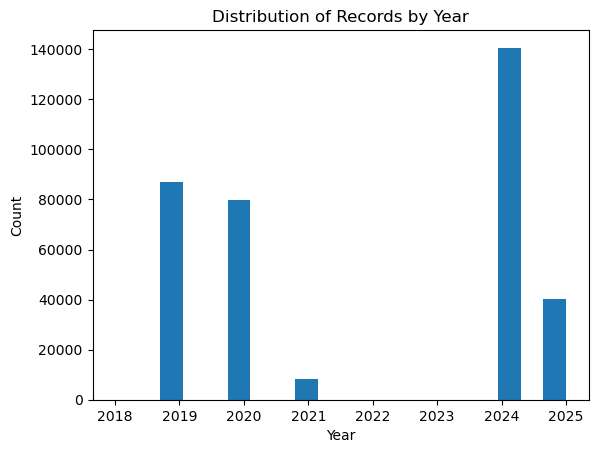

In [6]:
years = pd.to_datetime(data.RECEIVED_DATE).dt.year
plt.hist(years, bins=20)
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Distribution of Records by Year')
plt.show()

In [1]:
import os
import pyarrow.parquet as pq

base = "data/Prevailing Wage Program"
for year in sorted(os.listdir(base)):
    year_path = os.path.join(base, year)
    if not os.path.isdir(year_path):
        continue
    for f in sorted(os.listdir(year_path)):
        if f.endswith(".parquet"):
            meta = pq.read_metadata(os.path.join(year_path, f))
            print(f"{year}/{f}: {meta.num_rows:,} rows")

2010/PW_FY2010.parquet: 70,115 rows
2011/PW_FY2011.parquet: 103,390 rows
2012/PW_FY2012.parquet: 145,866 rows
2013/PW_FY2013.parquet: 124,883 rows
2014/PW_Case_Data_FY2014.parquet: 131,999 rows
2015/PW_Disclosure_Data_FY15_Q4.parquet: 139,120 rows
2016/PW_Disclosure_Data_FY16.parquet: 140,940 rows
2017/PW_Disclosure_Data_FY17.parquet: 182,725 rows
2018/PWD_Disclosure_Data_FY2018_EOY.parquet: 149,409 rows
2019/PW_Disclosure_Data_FY2019.parquet: 169,781 rows
2020/PW_Disclosure_Data_FY2020.parquet: 166,525 rows
2020/PW_Worksites_FY2020.parquet: 97,995 rows
2021/PW_Disclosure_Data_FY2021_old_form.parquet: 151,642 rows
2021/PW_Disclosure_Data_FY2021_revised_form.parquet: 8,420 rows
2021/PW_Worksites_FY2021_old_form.parquet: 69,458 rows
2021/PW_Worksites_FY2021_revised_form.parquet: 28,286 rows
2022/PW_Disclosure_Data_FY2022_Q4_old_form.parquet: 15,428 rows
2022/PW_Disclosure_Data_FY2022_Q4_revised_form.parquet: 171,475 rows
2022/PW_Worksites_FY2022_Q4_old_form.parquet: 1,731 rows
2022/PW_Wo

In [4]:
import pyarrow.parquet as pq
schema = pq.read_schema("amalgamated_data.parquet")
"DBA_SCA" in schema.names

False

## Data Validation Checks

In [11]:
# Load the final amalgamated parquet file
final_df = pd.read_parquet("amalgamated_data.parquet")
print(f"Final dataset shape: {final_df.shape}")
print(f"Total rows in final dataset: {len(final_df):,}")

# Set up base directory for validation
base = "data/Prevailing Wage Program"

Final dataset shape: (2375919, 128)
Total rows in final dataset: 2,375,919


In [ ]:
# Check 1: Sum of rows per year equals total rows
print("=" * 60)
print("CHECK 1: Row Count Validation")
print("=" * 60)

# Get row counts from original source files
source_counts = {}
for year in sorted(os.listdir(base)):
    year_path = os.path.join(base, year)
    if not os.path.isdir(year_path):
        continue
    for f in sorted(os.listdir(year_path)):
        if f.endswith(".parquet"):
            meta = pq.read_metadata(os.path.join(year_path, f))
            source_counts[int(year)] = meta.num_rows

# Get row counts from final dataset
final_counts = final_df['SOURCE_YEAR'].value_counts().sort_index()

print("\nSource vs Final row counts by year:")
print(f"{'Year':<8} {'Source':<12} {'Final':<12} {'Match':<8}")
print("-" * 40)

total_source = 0
total_final = 0
all_match = True

for year in sorted(source_counts.keys()):
    source = source_counts[year]
    final = final_counts.get(year, 0)
    match = "✓" if source == final else "✗ MISMATCH"
    
    if source != final:
        all_match = False
    
    print(f"{year:<8} {source:<12,} {final:<12,} {match:<8}")
    total_source += source
    total_final += final

print("-" * 40)
print(f"{'TOTAL':<8} {total_source:<12,} {total_final:<12,} {'✓' if total_source == total_final else '✗ MISMATCH'}")
print(f"\n{'Result':<20}: {'PASS' if all_match and total_source == total_final else 'FAIL'}")

# NOTE: "Source" here means 

CHECK 1: Row Count Validation

Source vs Final row counts by year:
Year     Source       Final        Match   
----------------------------------------
2010     70,115       70,115       ✓       
2011     103,390      103,390      ✓       
2012     145,866      145,866      ✓       
2013     124,883      124,883      ✓       
2014     131,999      131,999      ✓       
2015     139,120      139,120      ✓       
2016     140,940      140,940      ✓       
2017     182,725      182,725      ✓       
2018     149,409      149,409      ✓       
2019     169,781      169,781      ✓       
2020     97,995       166,525      ✗ MISMATCH
2021     28,286       8,420        ✗ MISMATCH
2022     154,468      171,475      ✗ MISMATCH
2023     163,207      252,209      ✗ MISMATCH
2024     157,153      237,926      ✗ MISMATCH
2025     14           181,136      ✗ MISMATCH
----------------------------------------
TOTAL    1,959,351    2,375,919    ✗ MISMATCH

Result              : FAIL


In [13]:
# Check 2: Verify all expected years are present
print("\n" + "=" * 60)
print("CHECK 2: Expected Years Validation")
print("=" * 60)

expected_years = sorted(set(int(year) for year in os.listdir(base) if os.path.isdir(os.path.join(base, year)) and year.isdigit()))
actual_years = sorted(final_df['SOURCE_YEAR'].unique())

print(f"\nExpected years: {expected_years}")
print(f"Actual years:   {actual_years}")
print(f"\nMissing years: {set(expected_years) - set(actual_years)}")
print(f"Extra years:   {set(actual_years) - set(expected_years)}")
print(f"Result: {'PASS' if expected_years == actual_years else 'FAIL'}")



CHECK 2: Expected Years Validation

Expected years: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Actual years:   [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

Missing years: set()
Extra years:   set()
Result: PASS


In [18]:
# Check 3: Null value analysis
print("=" * 60)
print("CHECK 3: Null Value Analysis")
print("=" * 60)

null_counts = final_df.isnull().sum()
total_nulls = null_counts.sum()
null_percentage = (total_nulls / (len(final_df) * len(final_df.columns))) * 100

print(f"\nTotal null values: {total_nulls:,}")
print(f"Null percentage: {null_percentage:.2f}%")
print(f"Total cells: {len(final_df) * len(final_df.columns):,}")

# Show ALL columns with more than 50% null values
threshold = len(final_df) * 0.5
high_null_cols = null_counts[null_counts > threshold].sort_values(ascending=False)
print(f"\nColumns with >50% null values ({len(high_null_cols)} columns):")
print(f"{'Column':<45} {'Nulls':>12} {'% Null':>8}")
print("-" * 67)
for col_name, count in high_null_cols.items():
    pct = count / len(final_df) * 100
    marker = " *** 100%" if count == len(final_df) else ""
    print(f"{col_name:<45} {count:>12,} {pct:>7.1f}%{marker}")

# Check for completely empty columns
empty_columns = null_counts[null_counts == len(final_df)]
if len(empty_columns) > 0:
    print(f"\n⚠ {len(empty_columns)} completely empty columns: {empty_columns.index.tolist()}")
else:
    print(f"\nNo completely empty columns")

CHECK 3: Null Value Analysis

Total null values: 194,311,061
Null percentage: 63.89%
Total cells: 304,117,632

Columns with >50% null values (93 columns):
Column                                               Nulls   % Null
-------------------------------------------------------------------
NAICS_CODE                                       2,375,919   100.0% *** 100%
PRIMARY_WORKSITE_CITY                            2,375,919   100.0% *** 100%
TRAVEL_REQUIRED                                  2,375,919   100.0% *** 100%
ALT_RES_FELLOWSHIP                               2,375,681   100.0%
ALT_FOREIGN_LANGUAGE                             2,375,345   100.0%
CENTER_DIRECTOR_REVIEW_DATE                      2,375,130   100.0%
ALT_TRAINING_NAME                                2,374,787   100.0%
ALT_TRAINING_MONTHS                              2,373,730    99.9%
SECOND_EDUCATION_MAJOR                           2,373,030    99.9%
ALT_OTHER_DEGREE                                 2,372,931    99.9%
SP

In [15]:
# Check 4: Schema and column consistency
print("\n" + "=" * 60)
print("CHECK 4: Schema and Column Consistency")
print("=" * 60)

print(f"\nTotal columns in final dataset: {len(final_df.columns)}")
print(f"Expected columns (from 2025 schema + SOURCE_YEAR): 127 + 1 = 128")

# Check if SOURCE_YEAR column exists
has_source_year = 'SOURCE_YEAR' in final_df.columns
print(f"\nSOURCE_YEAR column present: {'✓' if has_source_year else '✗'}")

# Check data types
print(f"\nData type summary:")
print(final_df.dtypes.value_counts())

print(f"\nColumns by data type:")
for dtype in final_df.dtypes.unique():
    cols = final_df.select_dtypes(include=[dtype]).columns.tolist()
    print(f"  {dtype}: {len(cols)} columns")



CHECK 4: Schema and Column Consistency

Total columns in final dataset: 128
Expected columns (from 2025 schema + SOURCE_YEAR): 127 + 1 = 128

SOURCE_YEAR column present: ✓

Data type summary:
object    127
int64       1
Name: count, dtype: int64

Columns by data type:
  object: 127 columns
  int64: 1 columns


In [19]:
# Check 5: Duplicate Analysis
print("=" * 60)
print("CHECK 5: Duplicate Analysis")
print("=" * 60)

# Show some duplicate CASE_NUMBERs so we can see what differs
dup_case_nums = final_df[final_df.duplicated(subset=['CASE_NUMBER'], keep=False)]
print(f"\nRows with duplicate CASE_NUMBERs: {len(dup_case_nums):,}")

# Pick a few example CASE_NUMBERs and show them
sample_cases = dup_case_nums['CASE_NUMBER'].value_counts().head(5).index
for case in sample_cases:
    rows = final_df[final_df['CASE_NUMBER'] == case]
    print(f"\n--- CASE_NUMBER: {case} ({len(rows)} rows) ---")
    # Show only non-null columns that differ between the rows
    non_null_cols = rows.columns[rows.notna().any()]
    differing = [c for c in non_null_cols if rows[c].nunique(dropna=False) > 1]
    if differing:
        print(f"Columns that differ between rows: {differing}")
        print(rows[['SOURCE_YEAR'] + differing].to_string(index=False))
    else:
        print("All non-null values are identical (true duplicates)")
        print(f"  SOURCE_YEAR: {rows['SOURCE_YEAR'].tolist()}")

CHECK 5: Duplicate Analysis

Rows with duplicate CASE_NUMBERs: 19,010

--- CASE_NUMBER: P-100-11143-720661 (3 rows) ---
Columns that differ between rows: ['CASE_STATUS', 'EMPLOYER_LEGAL_BUSINESS_NAME', 'PWD_SOC_CODE', 'PWD_WAGE_EXPIRATION_DATE', 'SOURCE_YEAR']
 SOURCE_YEAR                                  CASE_STATUS  EMPLOYER_LEGAL_BUSINESS_NAME PWD_SOC_CODE PWD_WAGE_EXPIRATION_DATE  SOURCE_YEAR
        2011                         DETERMINATION ISSUED ROSWELL PARK CANCER INSTITUTE   29-1063.00      2011-09-22 10:42:56         2011
        2011  PENDING REDETERMINATION REVIEW - UNASSIGNED ROSWELL PARK CANCER INSTITUTE   29-1063.00                     None         2011
        2012 REDETERMINATION REVIEW-OVERTURNED - MODIFIED                          None      29-1063      2012-06-30 00:00:00         2012

--- CASE_NUMBER: P-200-11109-773089 (3 rows) ---
Columns that differ between rows: ['CASE_STATUS', 'EMPLOYER_LEGAL_BUSINESS_NAME', 'PWD_SOC_CODE', 'PWD_SOC_TITLE', 'PWD_WAGE_RATE', '

In [20]:
# Check 5b: Most common values in EMPLOYER_POC_MIDDLE_NAME and AGENT_ATTORNEY_MIDDLE_NAME
print("=" * 60)
print("CHECK 5b: Middle Name Column Analysis")
print("=" * 60)

for col_name in ['EMPLOYER_POC_MIDDLE_NAME', 'AGENT_ATTORNEY_MIDDLE_NAME']:
    print(f"\n{col_name}:")
    non_null = final_df[col_name].dropna()
    print(f"  Non-null values: {len(non_null):,} / {len(final_df):,}")
    print(f"  Top 15 most common values:")
    print(non_null.value_counts().head(15).to_string())

CHECK 5b: Middle Name Column Analysis

EMPLOYER_POC_MIDDLE_NAME:
  Non-null values: 226,869 / 2,375,919
  Top 15 most common values:
EMPLOYER_POC_MIDDLE_NAME
R      15691
M       9327
D       8269
A       7175
A.      4852
J       4373
L       4240
M.      4231
S       3611
C.      2989
S.      2875
C       2619
E       2443
Ann     2442
J.      2389

AGENT_ATTORNEY_MIDDLE_NAME:
  Non-null values: 402,217 / 2,375,919
  Top 15 most common values:
AGENT_ATTORNEY_MIDDLE_NAME
M.       11150
T.        9911
S         9497
L         8639
M         8299
A         8011
L.        7796
B         7768
A.        7389
Marie     7311
J         6740
C         5946
R         5357
Bence     5260
J.        5036


In [ ]:
# Clean up: Remove 3 completely empty columns and 26 duplicate rows, then re-save
print("=" * 60)
print("CLEANUP: Removing empty columns and duplicate rows")
print("=" * 60)

rows_before = len(final_df)
cols_before = len(final_df.columns)

# Drop completely empty columns
cols_to_drop = empty_columns.index.tolist()
print(f"\nDropping {len(cols_to_drop)} empty columns: {cols_to_drop}")
final_df.drop(columns=cols_to_drop, inplace=True)

# Drop completely duplicate rows
final_df.drop_duplicates(inplace=True)

rows_after = len(final_df)
cols_after = len(final_df.columns)

print(f"\nBefore: {rows_before:,} rows x {cols_before} columns")
print(f"After:  {rows_after:,} rows x {cols_after} columns")
print(f"Removed: {rows_before - rows_after} duplicate rows, {cols_before - cols_after} empty columns")

# Re-save to parquet
print("\nSaving cleaned dataset to amalgamated_data.parquet...", end='', flush=True)
final_df.to_parquet("amalgamated_data.parquet", index=False)
print(" Done!")

import os
file_size_mb = os.path.getsize("amalgamated_data.parquet") / (1024 * 1024)
print(f"File size: {file_size_mb:.2f} MB")

CLEANUP: Removing empty columns and duplicate rows

Dropping 3 empty columns: ['NAICS_CODE', 'TRAVEL_REQUIRED', 'PRIMARY_WORKSITE_CITY']

Before: 2,375,919 rows x 128 columns
After:  2,375,906 rows x 125 columns
Removed: 13 duplicate rows, 3 empty columns

Saving cleaned dataset to amalgamated_data.parquet...

# NOTES
data from https://ohss.dhs.gov/topics/immigration/yearbook
Some unmapped columns were left after running amalgamate.py (unmapped_columns.csv)
I think all them are unmapped because they don't appear as keys in main_mapping_dict.csv
I think this is because when we went through the schemas manually a few months ago, we determined these columns had no equivalents in the 2025 schema. so, that they are unmapped is in line with our earlier intentions.